In [25]:
# CELL 1

from pathlib import Path

import pandas as pd
from IPython.display import display

from api.process_ai.process.pipeline.process_configs import get_process_config
from api.process_ai.process.core.registry_loader import load_registry, get_step_codes
from api.process_ai.process.core.validate import validate_events_df
from api.process_ai.process.core.features import build_case_feature_matrix, compute_baselines

In [26]:
# CELL 2

from pathlib import Path

PROCESS_KEY = "customs"

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "api").exists() and (p / "model").exists():
            return p
    raise FileNotFoundError("Could not find project root")

def to_abs_path(path_like: str | Path, project_root: Path) -> Path:
    p = Path(path_like)
    return p if p.is_absolute() else (project_root / p).resolve()

PROJECT_ROOT = find_project_root()

cfg = get_process_config(PROCESS_KEY)
PROCESS_CODE = cfg.process_code

DATA_DIR = to_abs_path(cfg.data_dir, PROJECT_ROOT)
REGISTRY_DIR = to_abs_path(cfg.registry_dir, PROJECT_ROOT)
MODEL_DIR = to_abs_path(cfg.model_dir, PROJECT_ROOT)
REPORT_DIR = to_abs_path(cfg.report_dir, PROJECT_ROOT)

EVENTS_PATH = DATA_DIR / "events.csv"
CONTEXT_PATH = DATA_DIR / "cases_context.csv"

print("PROJECT_ROOT :", PROJECT_ROOT)
print("PROCESS_KEY  :", PROCESS_KEY)
print("PROCESS_CODE :", PROCESS_CODE)
print("DATA_DIR     :", DATA_DIR)
print("REGISTRY_DIR :", REGISTRY_DIR)
print("MODEL_DIR    :", MODEL_DIR)
print("REPORT_DIR   :", REPORT_DIR)
print("EVENTS_PATH  :", EVENTS_PATH)
print("CONTEXT_PATH :", CONTEXT_PATH)

PROJECT_ROOT : D:\logistics_AI
PROCESS_KEY  : customs
PROCESS_CODE : IMPORT_CUSTOMS_CLEARANCE
DATA_DIR     : D:\logistics_AI\data\synth_optimal_3process_v1
REGISTRY_DIR : D:\logistics_AI\data\synth_optimal_3process_v1\registry
MODEL_DIR    : D:\logistics_AI\model\process_models
REPORT_DIR   : D:\logistics_AI\reports\customs
EVENTS_PATH  : D:\logistics_AI\data\synth_optimal_3process_v1\events.csv
CONTEXT_PATH : D:\logistics_AI\data\synth_optimal_3process_v1\cases_context.csv


In [27]:
# CELL 3

registry = load_registry(REGISTRY_DIR, PROCESS_CODE)
step_codes = get_step_codes(registry)

print("Number of step codes:", len(step_codes))
print("Step codes:")
print(step_codes)

Number of step codes: 16
Step codes:
['STEP_001_DOC_RECEIVED', 'STEP_002_DOC_VALIDATION', 'STEP_003_HS_CLASSIFICATION', 'STEP_004_SUBMIT_DECLARATION', 'STEP_005_RISK_CHANNELING', 'STEP_006_DOCUMENT_INSPECTION', 'STEP_007_PHYSICAL_INSPECTION_COMPLETE', 'STEP_008_LAB_TEST_COMPLETE', 'STEP_009_DUTY_TAX_INVOICE_ISSUED', 'STEP_010_PAYMENT_CONFIRMED', 'STEP_011_CLEARANCE_APPROVED', 'STEP_012_RELEASE_ORDER_ISSUED', 'STEP_013_CARGO_RELEASED', 'STEP_014_PORT_GATE_OUT', 'STEP_015_HANDOFF_TO_CARRIER', 'STEP_016_CUSTOMS_CLOSEOUT']


In [28]:
# CELL 4

events_df = pd.read_csv(EVENTS_PATH)
cases_context_df = pd.read_csv(CONTEXT_PATH)

print("events_df columns:")
print(events_df.columns.tolist())

print("\ncases_context_df columns:")
print(cases_context_df.columns.tolist())

# Filter events theo process_code
if "process_code" in events_df.columns:
    events_df = events_df[events_df["process_code"].astype(str) == PROCESS_CODE].copy()

# Filter cases_context theo process_code nếu có,
# còn nếu không có thì lọc theo case_id xuất hiện trong events_df
if "process_code" in cases_context_df.columns:
    cases_context_df = cases_context_df[
        cases_context_df["process_code"].astype(str) == PROCESS_CODE
    ].copy()
elif "case_id" in cases_context_df.columns and "case_id" in events_df.columns:
    valid_case_ids = events_df["case_id"].astype(str).unique().tolist()
    cases_context_df = cases_context_df[
        cases_context_df["case_id"].astype(str).isin(valid_case_ids)
    ].copy()

print("\nevents_df shape:", events_df.shape)
print("cases_context_df shape:", cases_context_df.shape)

display(events_df.head())
display(cases_context_df.head())

events_df columns:
['process_code', 'case_id', 'step_code', 'start_time', 'end_time']

cases_context_df columns:
['case_id', 'distance_bucket', 'service_level', 'warehouse_code', 'hub_code', 'port_code', 'is_cross_border']

events_df shape: (68576, 5)
cases_context_df shape: (4286, 7)


,process_code,case_id,step_code,start_time,end_time
179,IMPORT_CUSTOMS_CLEARANCE,ORD_1923969372,STEP_001_DOC_RECEIVED,2025-05-26T12:16:59,2025-05-26T12:41:58
180,IMPORT_CUSTOMS_CLEARANCE,ORD_1923969372,STEP_002_DOC_VALIDATION,2025-05-26T12:41:58,2025-05-26T12:53:24
181,IMPORT_CUSTOMS_CLEARANCE,ORD_1923969372,STEP_003_HS_CLASSIFICATION,2025-05-26T12:53:24,2025-05-26T13:11:02
182,IMPORT_CUSTOMS_CLEARANCE,ORD_1923969372,STEP_004_SUBMIT_DECLARATION,2025-05-26T13:11:02,2025-05-26T13:35:45
183,IMPORT_CUSTOMS_CLEARANCE,ORD_1923969372,STEP_005_RISK_CHANNELING,2025-05-26T13:35:45,2025-05-26T13:43:44


,case_id,distance_bucket,service_level,warehouse_code,hub_code,port_code,is_cross_border
3,ORD_1923969372,2,1,WH_HCM_01,HUB_BINH_TAN,HAI_PHONG,1
9,ORD_6304046335,1,2,WH_DN_01,HUB_BINH_TAN,HAI_PHONG,1
14,ORD_6642385052,3,0,WH_HCM_01,HUB_HA_NOI,DA_NANG,1
15,ORD_8452237344,4,1,WH_HCM_01,HUB_HA_NOI,CAI_MEP,1
16,ORD_5031563635,2,1,WH_HN_01,HUB_THU_DUC,CAI_MEP,1


In [29]:
# CELL 5

validated_events_df, validation_report = validate_events_df(
    events_df,
    process_code=PROCESS_CODE,
    valid_steps=step_codes,
    allow_unknown_steps=False,
)

print("validation_report.ok:", validation_report.ok)
print("validation_report.errors:")
print(validation_report.errors)
print("validation_report.warnings:")
print(validation_report.warnings)

print("validated_events_df shape:", validated_events_df.shape)
display(validated_events_df.head())

validation_report.ok: True
validation_report.errors:
[]
validation_report.warnings:
[]
validated_events_df shape: (68576, 6)


,process_code,case_id,step_code,start_time,end_time,duration_sec
179,IMPORT_CUSTOMS_CLEARANCE,ORD_1923969372,STEP_001_DOC_RECEIVED,2025-05-26 12:16:59,2025-05-26 12:41:58,1499.0
180,IMPORT_CUSTOMS_CLEARANCE,ORD_1923969372,STEP_002_DOC_VALIDATION,2025-05-26 12:41:58,2025-05-26 12:53:24,686.0
181,IMPORT_CUSTOMS_CLEARANCE,ORD_1923969372,STEP_003_HS_CLASSIFICATION,2025-05-26 12:53:24,2025-05-26 13:11:02,1058.0
182,IMPORT_CUSTOMS_CLEARANCE,ORD_1923969372,STEP_004_SUBMIT_DECLARATION,2025-05-26 13:11:02,2025-05-26 13:35:45,1483.0
183,IMPORT_CUSTOMS_CLEARANCE,ORD_1923969372,STEP_005_RISK_CHANNELING,2025-05-26 13:35:45,2025-05-26 13:43:44,479.0


In [30]:
# CELL 6

feature_df, feature_schema, feature_report = build_case_feature_matrix(
    validated_events_df,
    step_codes=step_codes,
    cases_context_df=cases_context_df,
    include_context_numeric=False,
)

print("feature_df shape:", feature_df.shape)
print("feature_schema keys:", list(feature_schema.keys()))
print("feature_report:", feature_report)

display(feature_df.head())

feature_df shape: (4286, 25)
feature_schema keys: ['step_codes', 'step_feature_cols', 'all_feature_cols']
feature_report: FeatureBuildReport(cases=4286, dropped_cases=0, repeated_case_count=0, missing_step_cases=0)


,STEP_001_DOC_RECEIVED_duration_min,STEP_002_DOC_VALIDATION_duration_min,STEP_003_HS_CLASSIFICATION_duration_min,STEP_004_SUBMIT_DECLARATION_duration_min,STEP_005_RISK_CHANNELING_duration_min,STEP_006_DOCUMENT_INSPECTION_duration_min,STEP_007_PHYSICAL_INSPECTION_COMPLETE_duration_min,STEP_008_LAB_TEST_COMPLETE_duration_min,STEP_009_DUTY_TAX_INVOICE_ISSUED_duration_min,STEP_010_PAYMENT_CONFIRMED_duration_min,...,STEP_016_CUSTOMS_CLOSEOUT_duration_min,total_process_time_min,max_step_duration_min,mean_step_duration_min,std_step_duration_min,step_count_present,missing_step_count,missing_step_flag,repeated_step_total,repeated_step_flag
case_id,,,,,,,,,,,,,,,,,,,,,
ORD_0000312750,24.800000,12.966667,20.716667,10.333333,10.200000,786.050000,171.833333,278.550000,170.300000,303.516667,...,20.500000,2671.566667,786.050000,166.972917,214.146247,16,0,0,0,0
ORD_0005053777,10.750000,7.533333,39.516667,58.683333,12.383333,308.000000,212.766667,282.700000,371.216667,170.900000,...,12.716667,2308.833333,371.216667,144.302083,144.828895,16,0,0,0,0
ORD_0005511584,23.266667,25.216667,18.550000,16.900000,43.550000,608.466667,256.783333,354.500000,190.583333,60.283333,...,44.000000,2836.566667,608.466667,177.285417,193.029767,16,0,0,0,0
ORD_0010926443,16.550000,28.216667,38.100000,40.533333,19.816667,324.283333,388.016667,194.333333,75.733333,98.400000,...,12.350000,2115.066667,401.766667,132.191667,148.706152,16,0,0,0,0
ORD_0015231940,38.866667,5.216667,43.716667,15.016667,11.800000,349.433333,450.833333,277.600000,216.033333,207.883333,...,37.650000,2599.900000,476.916667,162.493750,164.592133,16,0,0,0,0


In [31]:
# CELL 7

print("Feature columns:")
print(feature_df.columns.tolist())

print("\nFeature schema:")
print(feature_schema)

print("\nFeature report:")
print(feature_report)

display(feature_df.describe(include="all").T.head(20))

Feature columns:
['STEP_001_DOC_RECEIVED_duration_min', 'STEP_002_DOC_VALIDATION_duration_min', 'STEP_003_HS_CLASSIFICATION_duration_min', 'STEP_004_SUBMIT_DECLARATION_duration_min', 'STEP_005_RISK_CHANNELING_duration_min', 'STEP_006_DOCUMENT_INSPECTION_duration_min', 'STEP_007_PHYSICAL_INSPECTION_COMPLETE_duration_min', 'STEP_008_LAB_TEST_COMPLETE_duration_min', 'STEP_009_DUTY_TAX_INVOICE_ISSUED_duration_min', 'STEP_010_PAYMENT_CONFIRMED_duration_min', 'STEP_011_CLEARANCE_APPROVED_duration_min', 'STEP_012_RELEASE_ORDER_ISSUED_duration_min', 'STEP_013_CARGO_RELEASED_duration_min', 'STEP_014_PORT_GATE_OUT_duration_min', 'STEP_015_HANDOFF_TO_CARRIER_duration_min', 'STEP_016_CUSTOMS_CLOSEOUT_duration_min', 'total_process_time_min', 'max_step_duration_min', 'mean_step_duration_min', 'std_step_duration_min', 'step_count_present', 'missing_step_count', 'missing_step_flag', 'repeated_step_total', 'repeated_step_flag']

Feature schema:
{'step_codes': ['STEP_001_DOC_RECEIVED', 'STEP_002_DOC_VAL

,count,mean,std,min,25%,50%,75%,max
STEP_001_DOC_RECEIVED_duration_min,4286.0,22.866492,13.112300,1.783333,13.800000,19.983333,28.416667,129.750000
STEP_002_DOC_VALIDATION_duration_min,4286.0,14.228010,8.969156,1.800000,8.333333,12.066667,17.562500,119.333333
STEP_003_HS_CLASSIFICATION_duration_min,4286.0,23.444439,14.217769,2.266667,13.916667,19.950000,29.683333,202.400000
STEP_004_SUBMIT_DECLARATION_duration_min,4286.0,23.405744,13.964004,2.666667,13.833333,20.050000,28.900000,149.666667
STEP_005_RISK_CHANNELING_duration_min,4286.0,23.314878,14.077765,2.933333,13.737500,20.091667,29.141667,244.766667
STEP_006_DOCUMENT_INSPECTION_duration_min,4286.0,475.834690,275.778581,64.216667,278.254167,411.900000,601.445833,2435.283333
STEP_007_PHYSICAL_INSPECTION_COMPLETE_duration_min,4286.0,472.557591,274.172192,46.833333,277.004167,408.900000,591.029167,3086.033333
STEP_008_LAB_TEST_COMPLETE_duration_min,4286.0,468.038470,273.584501,53.350000,271.216667,399.750000,595.200000,1959.133333
STEP_009_DUTY_TAX_INVOICE_ISSUED_duration_min,4286.0,211.534173,131.028397,26.383333,123.500000,181.308333,260.666667,1440.000000
STEP_010_PAYMENT_CONFIRMED_duration_min,4286.0,210.128270,128.363265,24.966667,125.195833,180.241667,260.095833,1393.866667


In [32]:
# CELL 8

baselines = compute_baselines(
    feature_df,
    step_codes=step_codes,
)

print("Baseline keys:")
print(baselines.keys())

print("\nStep baseline sample:")
display(pd.DataFrame(baselines.get("steps", {})).T.head())

Baseline keys:
dict_keys(['steps', 'total_process_time_min', 'n_cases_for_baseline'])

Step baseline sample:


,mean,std,p95,p99,missing_rate
STEP_001_DOC_RECEIVED,22.866492,13.110771,47.445833,68.829167,0.0
STEP_002_DOC_VALIDATION,14.228010,8.968110,30.150000,46.135000,0.0
STEP_003_HS_CLASSIFICATION,23.444439,14.216110,48.308333,69.760000,0.0
STEP_004_SUBMIT_DECLARATION,23.405744,13.962374,50.083333,73.331667,0.0
STEP_005_RISK_CHANNELING,23.314878,14.076122,49.154167,71.950833,0.0


In [33]:
# CELL 9

case_counts = (
    validated_events_df.groupby("case_id")
    .size()
    .reset_index(name="event_count")
    .sort_values("event_count", ascending=False)
)

print("Number of unique cases:", case_counts["case_id"].nunique())
display(case_counts.head(10))

Number of unique cases: 4286


,case_id,event_count
0,ORD_0000312750,16
1,ORD_0005053777,16
2,ORD_0005511584,16
3,ORD_0010926443,16
4,ORD_0015231940,16
5,ORD_0015850954,16
6,ORD_0017772566,16
7,ORD_0019124482,16
8,ORD_0020802216,16
9,ORD_0023350638,16


In [34]:
# CELL 10

step_counts = (
    validated_events_df["step_code"]
    .value_counts(dropna=False)
    .reset_index()
)
step_counts.columns = ["step_code", "count"]

display(step_counts)

,step_code,count
0,STEP_001_DOC_RECEIVED,4286
1,STEP_002_DOC_VALIDATION,4286
2,STEP_003_HS_CLASSIFICATION,4286
3,STEP_004_SUBMIT_DECLARATION,4286
4,STEP_005_RISK_CHANNELING,4286
5,STEP_006_DOCUMENT_INSPECTION,4286
6,STEP_007_PHYSICAL_INSPECTION_COMPLETE,4286
7,STEP_008_LAB_TEST_COMPLETE,4286
8,STEP_009_DUTY_TAX_INVOICE_ISSUED,4286
9,STEP_010_PAYMENT_CONFIRMED,4286


In [35]:
# CELL 11

missing_step_cases = []

total_cases = feature_df.index.astype(str).nunique()

for s in step_codes:
    case_has_step = (
        validated_events_df.loc[validated_events_df["step_code"] == s, "case_id"]
        .astype(str)
        .unique()
    )

    missing_count = total_cases - len(case_has_step)

    missing_step_cases.append({
        "step_code": s,
        "missing_case_count": missing_count,
    })

missing_step_df = pd.DataFrame(missing_step_cases).sort_values(
    "missing_case_count", ascending=False
)

display(missing_step_df)

,step_code,missing_case_count
0,STEP_001_DOC_RECEIVED,0
1,STEP_002_DOC_VALIDATION,0
2,STEP_003_HS_CLASSIFICATION,0
3,STEP_004_SUBMIT_DECLARATION,0
4,STEP_005_RISK_CHANNELING,0
5,STEP_006_DOCUMENT_INSPECTION,0
6,STEP_007_PHYSICAL_INSPECTION_COMPLETE,0
7,STEP_008_LAB_TEST_COMPLETE,0
8,STEP_009_DUTY_TAX_INVOICE_ISSUED,0
9,STEP_010_PAYMENT_CONFIRMED,0


In [36]:
# CELL 12

print("Final check:")
print("- Registry loaded:", registry is not None)
print("- Step codes loaded:", len(step_codes) > 0)
print("- Events validated:", validation_report.ok)
print("- Feature matrix ready:", not feature_df.empty)
print("- Baselines computed:", bool(baselines))

Final check:
- Registry loaded: True
- Step codes loaded: True
- Events validated: True
- Feature matrix ready: True
- Baselines computed: True


In [37]:
# CELL 13

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

REPORT_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY = "#1f4e79"
SECONDARY = "#5b9bd5"
ACCENT = "#9dc3e6"
GRID = "#d9d9d9"
TEXT = "#222222"

plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.labelcolor"] = TEXT
plt.rcParams["xtick.color"] = TEXT
plt.rcParams["ytick.color"] = TEXT
plt.rcParams["text.color"] = TEXT
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

def pretty_step_label(x: str) -> str:
    x = str(x)
    x = x.replace("STEP_", "")
    parts = x.split("_", 1)
    if len(parts) == 2 and parts[0].isdigit():
        x = parts[1]
    x = x.replace("_", " ").title()
    return x[:32] + "..." if len(x) > 32 else x

def style_axes(ax, grid_axis="x"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")
    ax.grid(axis=grid_axis, color=GRID, linestyle="-", linewidth=0.8, alpha=0.7)
    ax.set_axisbelow(True)

def save_and_show(fig, path: Path):
    fig.tight_layout()
    fig.savefig(path, dpi=240, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved:", path)

In [38]:
# CELL 14

summary_rows = []

summary_rows.append({
    "metric": "process_code",
    "value": PROCESS_CODE,
})

summary_rows.append({
    "metric": "num_step_codes",
    "value": len(step_codes),
})

summary_rows.append({
    "metric": "validated_event_rows",
    "value": int(len(validated_events_df)),
})

summary_rows.append({
    "metric": "num_cases",
    "value": int(feature_df.shape[0]),
})

summary_rows.append({
    "metric": "num_features",
    "value": int(feature_df.shape[1]),
})

summary_rows.append({
    "metric": "dropped_cases",
    "value": int(getattr(feature_report, "dropped_cases", 0)),
})

summary_rows.append({
    "metric": "repeated_case_count",
    "value": int(getattr(feature_report, "repeated_case_count", 0)),
})

summary_rows.append({
    "metric": "missing_step_cases",
    "value": int(getattr(feature_report, "missing_step_cases", 0)),
})

summary_df = pd.DataFrame(summary_rows)

display(summary_df)

,metric,value
0,process_code,IMPORT_CUSTOMS_CLEARANCE
1,num_step_codes,16
2,validated_event_rows,68576
3,num_cases,4286
4,num_features,25
5,dropped_cases,0
6,repeated_case_count,0
7,missing_step_cases,0


In [39]:
# CELL 15

customs_pattern = r"DECLAR|DOC|DOCUMENT|VALIDAT|AMEND|REVIEW|INSPECT|CUSTOMS|DUTY|TAX|RELEASE|CLEARANCE"

step_duration_summary_df = (
    validated_events_df.assign(
        start_time=pd.to_datetime(validated_events_df["start_time"]),
        end_time=pd.to_datetime(validated_events_df["end_time"]),
    )
    .assign(duration_min=lambda d: (d["end_time"] - d["start_time"]).dt.total_seconds() / 60.0)
    .groupby("step_code")["duration_min"]
    .agg(["count", "mean", "median", "max"])
    .reset_index()
)

step_duration_summary_df["step_label"] = step_duration_summary_df["step_code"].map(pretty_step_label)

customs_step_duration_df = step_duration_summary_df[
    step_duration_summary_df["step_code"].astype(str).str.contains(customs_pattern, case=False, regex=True)
].copy()

if customs_step_duration_df.empty:
    customs_step_duration_df = step_duration_summary_df.copy()

customs_step_duration_df = customs_step_duration_df.sort_values("mean", ascending=False)

display(customs_step_duration_df)

,step_code,count,mean,median,max,step_label
5,STEP_006_DOCUMENT_INSPECTION,4286,475.834690,411.900000,2435.283333,Document Inspection
6,STEP_007_PHYSICAL_INSPECTION_COMPLETE,4286,472.557591,408.900000,3086.033333,Physical Inspection Complete
12,STEP_013_CARGO_RELEASED,4286,283.382031,241.208333,1440.000000,Cargo Released
11,STEP_012_RELEASE_ORDER_ISSUED,4286,279.592892,239.216667,1705.550000,Release Order Issued
10,STEP_011_CLEARANCE_APPROVED,4286,278.250669,237.458333,1440.000000,Clearance Approved
8,STEP_009_DUTY_TAX_INVOICE_ISSUED,4286,211.534173,181.308333,1440.000000,Duty Tax Invoice Issued
3,STEP_004_SUBMIT_DECLARATION,4286,23.405744,20.050000,149.666667,Submit Declaration
15,STEP_016_CUSTOMS_CLOSEOUT,4286,23.001392,20.033333,232.016667,Customs Closeout
0,STEP_001_DOC_RECEIVED,4286,22.866492,19.983333,129.750000,Doc Received
1,STEP_002_DOC_VALIDATION,4286,14.228010,12.066667,119.333333,Doc Validation


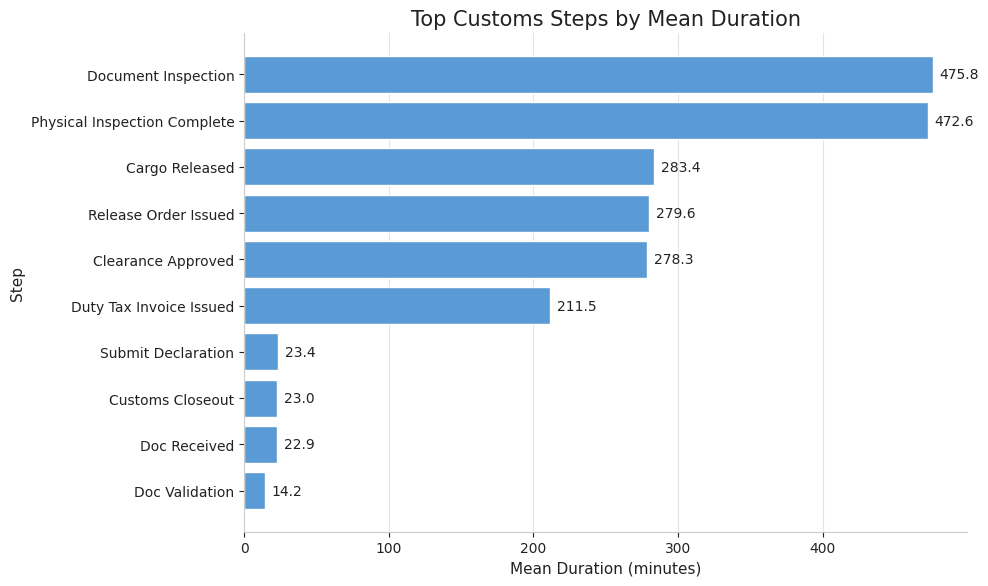

Saved: D:\logistics_AI\reports\customs\customs_top_customs_mean_duration.png


In [40]:
# CELL 16

top_mean_df = customs_step_duration_df.head(10).copy().sort_values("mean", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_mean_df["step_label"], top_mean_df["mean"], color=SECONDARY, edgecolor="white")
ax.set_title("Top Customs Steps by Mean Duration")
ax.set_xlabel("Mean Duration (minutes)")
ax.set_ylabel("Step")
style_axes(ax, grid_axis="x")

for bar in bars:
    w = bar.get_width()
    ax.text(
        w + max(top_mean_df["mean"]) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{w:.1f}",
        va="center",
        ha="left",
        fontsize=10,
    )

mean_duration_path = REPORT_DIR / f"{PROCESS_KEY}_top_customs_mean_duration.png"
save_and_show(fig, mean_duration_path)

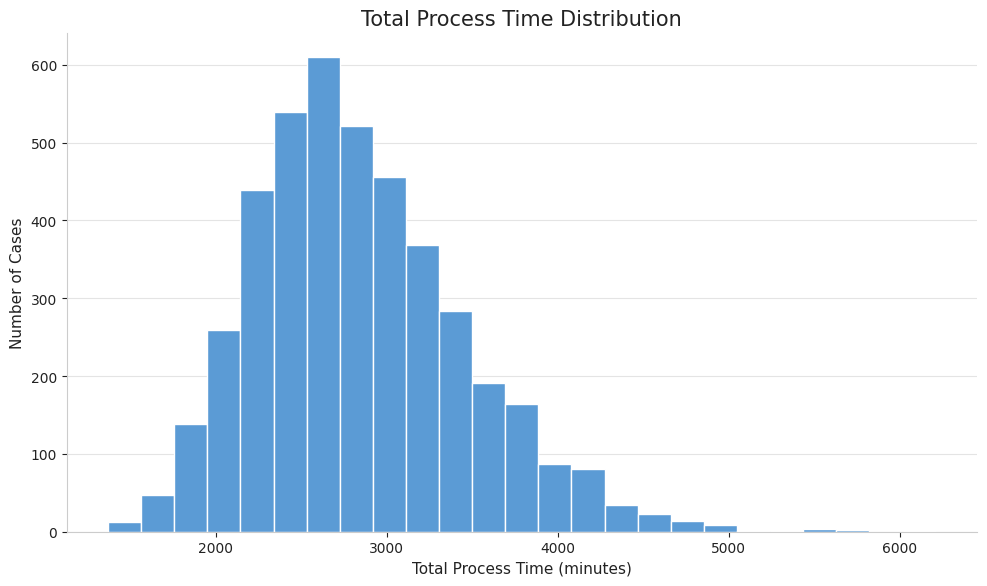

Saved: D:\logistics_AI\reports\customs\customs_total_process_time_hist.png


In [41]:
# CELL 17

if "total_process_time_min" in feature_df.columns:
    total_time_series = feature_df["total_process_time_min"].copy()
else:
    step_duration_cols = [c for c in feature_df.columns if str(c).endswith("_duration_min")]
    total_time_series = feature_df[step_duration_cols].sum(axis=1)

total_time_df = pd.DataFrame({
    "case_id": feature_df.index.astype(str),
    "total_process_time_min": total_time_series.values,
}).sort_values("total_process_time_min", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(total_time_df["total_process_time_min"], bins=25, color=SECONDARY, edgecolor="white")
ax.set_title("Total Process Time Distribution")
ax.set_xlabel("Total Process Time (minutes)")
ax.set_ylabel("Number of Cases")
style_axes(ax, grid_axis="y")

total_time_hist_path = REPORT_DIR / f"{PROCESS_KEY}_total_process_time_hist.png"
save_and_show(fig, total_time_hist_path)

In [42]:
# CELL 18

baseline_step_df = pd.DataFrame(baselines.get("steps", {})).T.reset_index()
baseline_step_df = baseline_step_df.rename(columns={"index": "step_code"})

for col in ["mean", "std", "p95", "count"]:
    if col in baseline_step_df.columns:
        baseline_step_df[col] = pd.to_numeric(baseline_step_df[col], errors="coerce")

baseline_step_df["step_label"] = baseline_step_df["step_code"].map(pretty_step_label)

customs_baseline_df = baseline_step_df[
    baseline_step_df["step_code"].astype(str).str.contains(customs_pattern, case=False, regex=True)
].copy()

if customs_baseline_df.empty:
    customs_baseline_df = baseline_step_df.copy()

customs_baseline_df = customs_baseline_df.sort_values("p95", ascending=False)

display(customs_baseline_df)

,step_code,mean,std,p95,p99,missing_rate,step_label
6,STEP_007_PHYSICAL_INSPECTION_COMPLETE,472.557591,274.140205,1018.504167,1440.000000,0.0,Physical Inspection Complete
5,STEP_006_DOCUMENT_INSPECTION,475.834690,275.746407,1016.933333,1440.000000,0.0,Document Inspection
12,STEP_013_CARGO_RELEASED,283.382031,171.706275,611.191667,872.419167,0.0,Cargo Released
11,STEP_012_RELEASE_ORDER_ISSUED,279.592892,168.850495,593.958333,880.072500,0.0,Release Order Issued
10,STEP_011_CLEARANCE_APPROVED,278.250669,164.032897,589.066667,852.728333,0.0,Clearance Approved
8,STEP_009_DUTY_TAX_INVOICE_ISSUED,211.534173,131.013110,452.237500,685.268333,0.0,Duty Tax Invoice Issued
3,STEP_004_SUBMIT_DECLARATION,23.405744,13.962374,50.083333,73.331667,0.0,Submit Declaration
15,STEP_016_CUSTOMS_CLOSEOUT,23.001392,13.802095,48.433333,67.685000,0.0,Customs Closeout
0,STEP_001_DOC_RECEIVED,22.866492,13.110771,47.445833,68.829167,0.0,Doc Received
1,STEP_002_DOC_VALIDATION,14.228010,8.968110,30.150000,46.135000,0.0,Doc Validation


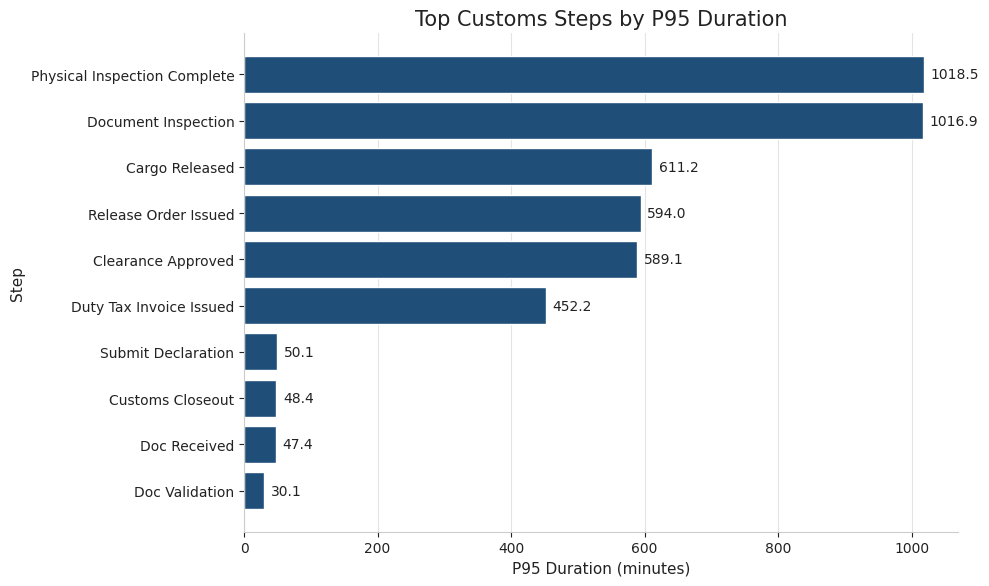

Saved: D:\logistics_AI\reports\customs\customs_top_customs_p95_duration.png


In [43]:
# CELL 19

top_p95_df = customs_baseline_df.head(10).copy().sort_values("p95", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_p95_df["step_label"], top_p95_df["p95"], color=PRIMARY, edgecolor="white")
ax.set_title("Top Customs Steps by P95 Duration")
ax.set_xlabel("P95 Duration (minutes)")
ax.set_ylabel("Step")
style_axes(ax, grid_axis="x")

for bar in bars:
    w = bar.get_width()
    ax.text(
        w + max(top_p95_df["p95"]) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{w:.1f}",
        va="center",
        ha="left",
        fontsize=10,
    )

baseline_p95_path = REPORT_DIR / f"{PROCESS_KEY}_top_customs_p95_duration.png"
save_and_show(fig, baseline_p95_path)

In [44]:
# CELL 20

missing_step_cases = []
total_cases = feature_df.index.astype(str).nunique()

for s in step_codes:
    case_has_step = (
        validated_events_df.loc[validated_events_df["step_code"] == s, "case_id"]
        .astype(str)
        .nunique()
    )
    missing_step_cases.append({
        "step_code": s,
        "missing_case_count": total_cases - case_has_step,
    })

missing_step_df = pd.DataFrame(missing_step_cases).sort_values("missing_case_count", ascending=False)
missing_step_df["step_label"] = missing_step_df["step_code"].map(pretty_step_label)

display(missing_step_df)

if missing_step_df["missing_case_count"].max() > 0:
    top_missing_df = missing_step_df.head(10).copy().sort_values("missing_case_count", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(top_missing_df["step_label"], top_missing_df["missing_case_count"], color=ACCENT, edgecolor="white")
    ax.set_title("Top Steps with Missing Cases")
    ax.set_xlabel("Number of Missing Cases")
    ax.set_ylabel("Step")
    style_axes(ax, grid_axis="x")

    for bar in bars:
        w = bar.get_width()
        ax.text(w + max(top_missing_df["missing_case_count"].max(), 1) * 0.01,
                bar.get_y() + bar.get_height()/2,
                f"{int(w)}", va="center", ha="left", fontsize=10)

    missing_step_path = REPORT_DIR / f"{PROCESS_KEY}_top_missing_step_cases.png"
    save_and_show(fig, missing_step_path)
else:
    print("No missing-step issue detected. Skipping missing-step chart.")

,step_code,missing_case_count,step_label
0,STEP_001_DOC_RECEIVED,0,Doc Received
1,STEP_002_DOC_VALIDATION,0,Doc Validation
2,STEP_003_HS_CLASSIFICATION,0,Hs Classification
3,STEP_004_SUBMIT_DECLARATION,0,Submit Declaration
4,STEP_005_RISK_CHANNELING,0,Risk Channeling
5,STEP_006_DOCUMENT_INSPECTION,0,Document Inspection
6,STEP_007_PHYSICAL_INSPECTION_COMPLETE,0,Physical Inspection Complete
7,STEP_008_LAB_TEST_COMPLETE,0,Lab Test Complete
8,STEP_009_DUTY_TAX_INVOICE_ISSUED,0,Duty Tax Invoice Issued
9,STEP_010_PAYMENT_CONFIRMED,0,Payment Confirmed


No missing-step issue detected. Skipping missing-step chart.


In [45]:
# CELL 21

display(
    customs_step_duration_df.sort_values("median", ascending=False).head(10)[
        ["step_code", "count", "mean", "median", "max"]
    ]
)

,step_code,count,mean,median,max
5,STEP_006_DOCUMENT_INSPECTION,4286,475.834690,411.900000,2435.283333
6,STEP_007_PHYSICAL_INSPECTION_COMPLETE,4286,472.557591,408.900000,3086.033333
12,STEP_013_CARGO_RELEASED,4286,283.382031,241.208333,1440.000000
11,STEP_012_RELEASE_ORDER_ISSUED,4286,279.592892,239.216667,1705.550000
10,STEP_011_CLEARANCE_APPROVED,4286,278.250669,237.458333,1440.000000
8,STEP_009_DUTY_TAX_INVOICE_ISSUED,4286,211.534173,181.308333,1440.000000
3,STEP_004_SUBMIT_DECLARATION,4286,23.405744,20.050000,149.666667
15,STEP_016_CUSTOMS_CLOSEOUT,4286,23.001392,20.033333,232.016667
0,STEP_001_DOC_RECEIVED,4286,22.866492,19.983333,129.750000
1,STEP_002_DOC_VALIDATION,4286,14.228010,12.066667,119.333333


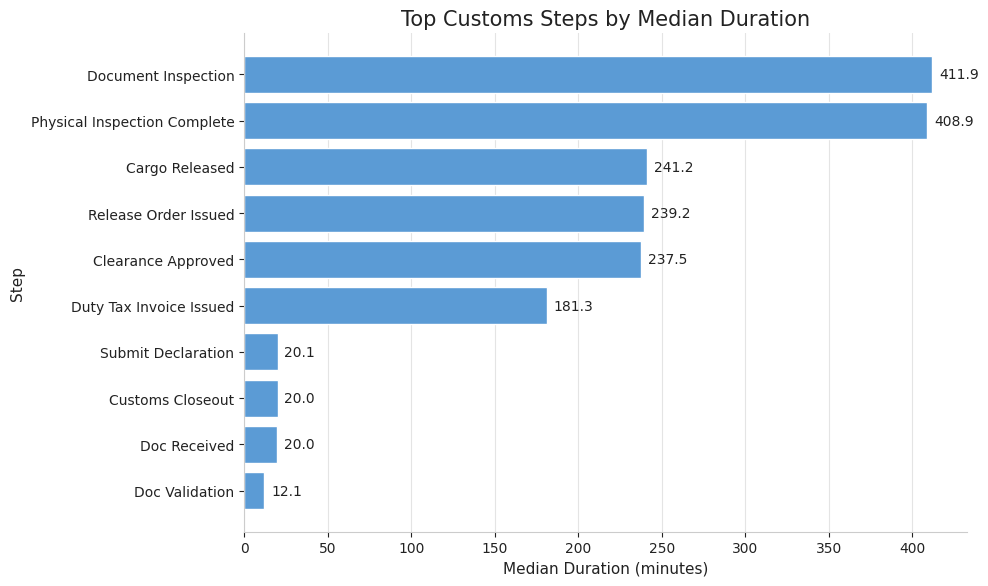

Saved: D:\logistics_AI\reports\customs\customs_top_customs_median_duration.png


In [46]:
# CELL 22

top_median_df = (
    customs_step_duration_df.sort_values("median", ascending=False)
    .head(10)
    .copy()
    .sort_values("median", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_median_df["step_label"], top_median_df["median"], color=SECONDARY, edgecolor="white")
ax.set_title("Top Customs Steps by Median Duration")
ax.set_xlabel("Median Duration (minutes)")
ax.set_ylabel("Step")
style_axes(ax, grid_axis="x")

for bar in bars:
    w = bar.get_width()
    ax.text(
        w + max(top_median_df["median"]) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{w:.1f}",
        va="center",
        ha="left",
        fontsize=10,
    )

step_median_path = REPORT_DIR / f"{PROCESS_KEY}_top_customs_median_duration.png"
save_and_show(fig, step_median_path)

In [47]:
# CELL 23

summary_df.to_csv(REPORT_DIR / f"{PROCESS_KEY}_summary_metrics.csv", index=False)
total_time_df.to_csv(REPORT_DIR / f"{PROCESS_KEY}_total_process_time.csv", index=False)
baseline_step_df.to_csv(REPORT_DIR / f"{PROCESS_KEY}_baseline_steps.csv", index=False)
step_duration_summary_df.to_csv(REPORT_DIR / f"{PROCESS_KEY}_step_duration_summary.csv", index=False)
missing_step_df.to_csv(REPORT_DIR / f"{PROCESS_KEY}_missing_steps.csv", index=False)

print("Saved CSV files to:", REPORT_DIR)

Saved CSV files to: D:\logistics_AI\reports\customs


In [48]:
# CELL 24

generated_files = [
    REPORT_DIR / f"{PROCESS_KEY}_top_step_mean_duration.png",
    REPORT_DIR / f"{PROCESS_KEY}_total_process_time_hist.png",
    REPORT_DIR / f"{PROCESS_KEY}_top_step_p95.png",
    REPORT_DIR / f"{PROCESS_KEY}_top_step_median_duration.png",
    REPORT_DIR / f"{PROCESS_KEY}_summary_metrics.csv",
    REPORT_DIR / f"{PROCESS_KEY}_total_process_time.csv",
    REPORT_DIR / f"{PROCESS_KEY}_baseline_steps.csv",
    REPORT_DIR / f"{PROCESS_KEY}_step_duration_summary.csv",
    REPORT_DIR / f"{PROCESS_KEY}_missing_steps.csv",
]

optional_missing_chart = REPORT_DIR / f"{PROCESS_KEY}_top_missing_step_cases.png"
if optional_missing_chart.exists():
    generated_files.append(optional_missing_chart)

for f in generated_files:
    print(f.exists(), "-", f)

False - D:\logistics_AI\reports\customs\customs_top_step_mean_duration.png
True - D:\logistics_AI\reports\customs\customs_total_process_time_hist.png
False - D:\logistics_AI\reports\customs\customs_top_step_p95.png
False - D:\logistics_AI\reports\customs\customs_top_step_median_duration.png
True - D:\logistics_AI\reports\customs\customs_summary_metrics.csv
True - D:\logistics_AI\reports\customs\customs_total_process_time.csv
True - D:\logistics_AI\reports\customs\customs_baseline_steps.csv
True - D:\logistics_AI\reports\customs\customs_step_duration_summary.csv
True - D:\logistics_AI\reports\customs\customs_missing_steps.csv
